In [36]:
import pandas as pd

df = pd.read_csv("../data/customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [37]:
#Data set inspection
df.shape

(200, 5)

In [38]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [39]:
rows_duplicated = df.duplicated().sum()
print('Number of duplicated rows : ', rows_duplicated)

Number of duplicated rows :  0


In [40]:
df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [41]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [42]:
#Data Preprocessing 
#Standardisation of data using StandardScaler or MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

features = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_features, columns=features.columns)

scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,0.019231,0.000000,0.387755
1,0.057692,0.000000,0.816327
2,0.038462,0.008197,0.051020
3,0.096154,0.008197,0.775510
4,0.250000,0.016393,0.397959


In [43]:
from sklearn.preprocessing import StandardScaler

features = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

scaler = StandardScaler()

scaled_features2 = scaler.fit_transform(features)

scaled_df2 = pd.DataFrame(scaled_features2, columns=features.columns)

scaled_df2.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


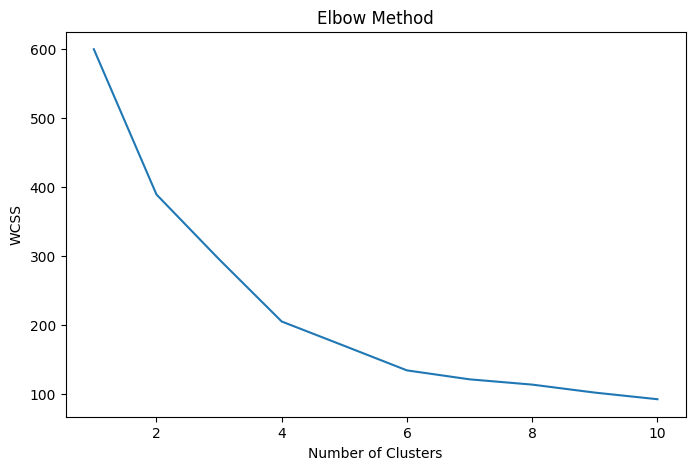

In [44]:
#Clustering

X = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_scaled = scaled_df2[['Age','Annual Income (k$)','Spending Score (1-100)']]

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

### Optimal number of clusters 

The optimal number of clusters is equal to the number of elbow .
So in the above plot we ca see that ther eare 3 elbow points therefore the opktimal number of clusters is 3 according to the Elbow method .

In [46]:
#Silhouette method
from sklearn.metrics import silhouette_score

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    print("Clusters:", k, "Score:", score)



Clusters: 2 Score: 0.33547192894004574
Clusters: 3 Score: 0.3579234303882264
Clusters: 4 Score: 0.4039582785148566
Clusters: 5 Score: 0.40846873777345605
Clusters: 6 Score: 0.43106526216603014
Clusters: 7 Score: 0.410091114520974
Clusters: 8 Score: 0.3673663165322295
Clusters: 9 Score: 0.37442148555078425
Clusters: 10 Score: 0.36186970479722974


In [47]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,3
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


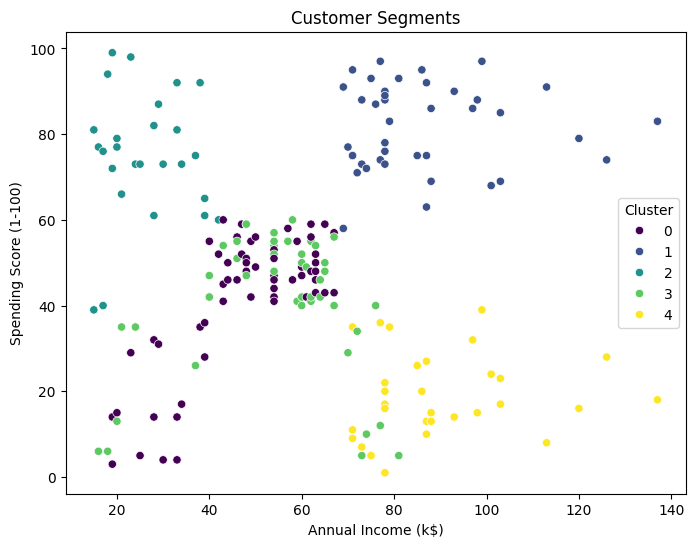

In [48]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title("Customer Segments")
plt.show()

In [49]:
#2D Scatter Plot using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [50]:
df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])

df_pca['Cluster'] = df['Cluster']

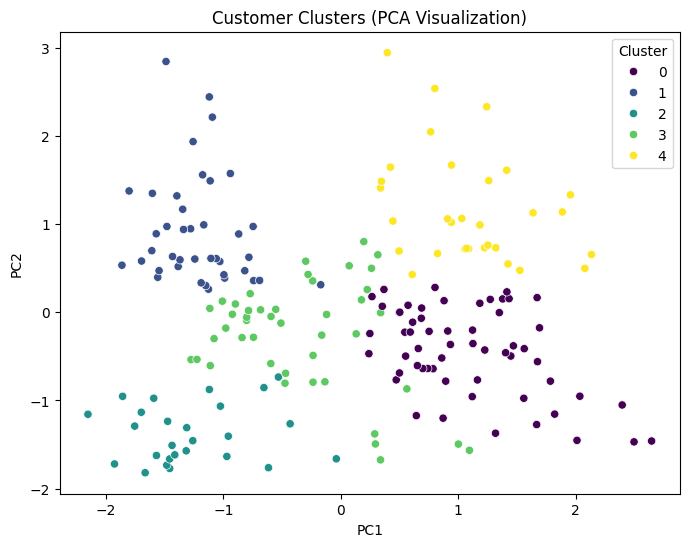

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=df_pca,
    palette='viridis'
)

plt.title("Customer Clusters (PCA Visualization)")
plt.show()

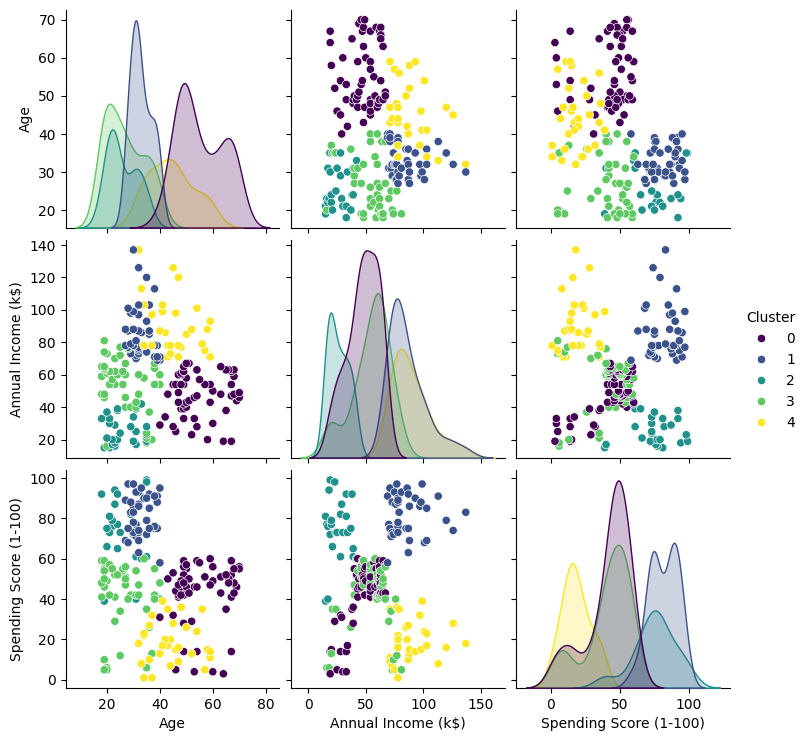

In [52]:
#Pair plotting
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(
    df,
    vars=['Age','Annual Income (k$)','Spending Score (1-100)'],
    hue='Cluster',
    palette='viridis'
)

plt.show()



In [53]:
centroids = kmeans.cluster_centers_

In [54]:
from sklearn.preprocessing import StandardScaler
centroids_original = scaler.inverse_transform(centroids)


In [55]:
centroid_df = pd.DataFrame(
    centroids_original,
    columns=['Age','Annual Income','Spending Score']
)

print(centroid_df)

         Age  Annual Income  Spending Score
0  55.275862      47.620690       41.706897
1  32.875000      86.100000       81.525000
2  25.769231      26.115385       74.846154
3  26.733333      54.311111       40.911111
4  44.387097      89.774194       18.483871


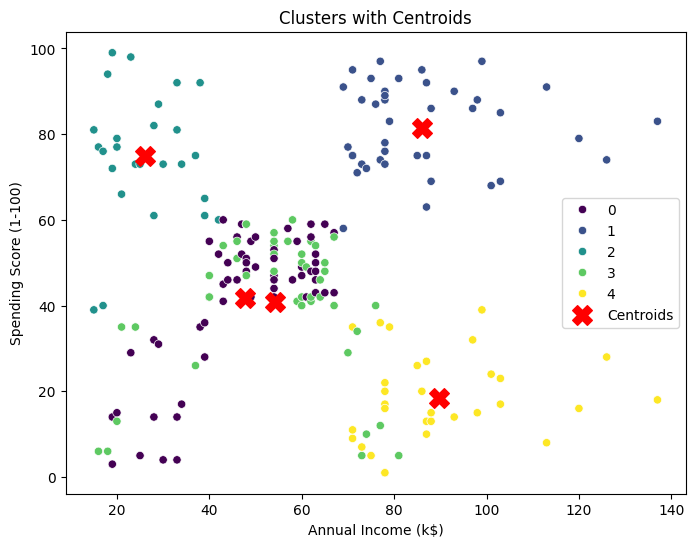

In [57]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)

# Plot centroids
plt.scatter(
    centroid_df['Annual Income'],
    centroid_df['Spending Score'],
    color='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.legend()
plt.title("Clusters with Centroids")
plt.show()

In [58]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,3
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


## Recommendations Based on Customer Segmentation

### 1. High Income – High Spending Customers (Cluster 1)

This group consists of customers with high annual income and high spending scores. They represent the most valuable segment for the business.

**Recommendations:**

* Target these customers with **premium products and exclusive offers**.
* Introduce **loyalty programs**, VIP memberships, and early access to new products.
* Provide personalized experiences to retain their engagement.

---

### 2. Low Income – High Spending Customers (Cluster 2)

These customers have lower income but exhibit high spending behavior.

**Recommendations:**

* Offer **discounts, deals, and promotional bundles** to maintain their purchasing frequency.
* Introduce **installment plans or flexible pricing** to support continued spending.
* Focus on **value-for-money marketing strategies**.

---

### 3. Medium Income – Medium Spending Customers (Cluster 0 & 3)

This segment represents the average customers with moderate income and spending patterns.

**Recommendations:**

* Target with **seasonal promotions and personalized recommendations**.
* Encourage higher spending through **upselling and cross-selling strategies**.
* Provide incentives such as **reward points or cashback offers**.

---

### 4. High Income – Low Spending Customers (Cluster 4)

These customers have strong purchasing power but low spending engagement.

**Recommendations:**

* Use **targeted marketing campaigns** to understand and influence their preferences.
* Offer **premium trials, personalized recommendations, or exclusive discounts**.
* Focus on converting them into high-spending customers.

---

### 5. Low Income – Low Spending Customers

This segment contributes the least to revenue.

**Recommendations:**

* Avoid excessive marketing expenditure on this group.
* Use **cost-effective campaigns** such as email marketing or basic promotions.
* Focus resources on higher-value segments instead.

---

### Overall Business Strategy

* Prioritize high-value segments (high income and high spending) for revenue growth.
* Use targeted promotions to convert underperforming segments.
* Implement data-driven personalization to improve customer engagement across all segments.
